# Aplicação Pedro Rodrigues e Pedro Miguel de Dual em prog. inteira

Fizemos para apresentação um exemplo dos materias nas referências e decidimos fazer um código com uma aplicação em um problema diferente

In [1]:
from pulp import *

### Problema Primal

**Função Objetivo (Maximizar):**
`Z = 5x + 8y`

**Sujeito às seguintes restrições:**
* `3x + 2y <= 15`
* `x - y >= -4`
* `x e y >= 0`

A solução `sem a restrição inteira`:

In [2]:
print("1. Solução Primal (Contínua) ")

prob_lp = LpProblem("Primal_LP", LpMaximize)

x = LpVariable('x', lowBound=0, cat='Continuous')
y = LpVariable('y', lowBound=0, cat='Continuous')

prob_lp += 5*x + 8*y

prob_lp += 3*x + 2*y <= 15
prob_lp += x - y >= -4

prob_lp.solve()

print(f"Status: {LpStatus[prob_lp.status]}")
print(f"x1 = {value(x)}")
print(f"x2 = {value(y)}")
print(f"Valor Ótimo = {value(prob_lp.objective)}")

1. Solução Primal (Contínua) 
Status: Optimal
x1 = 1.4
x2 = 5.4
Valor Ótimo = 50.2


Segue uma ``representação visual da solução``, onde em ``branco`` temos a região possível e em ``vermelho`` a curva de nível de valores objetivos no ponto máximo

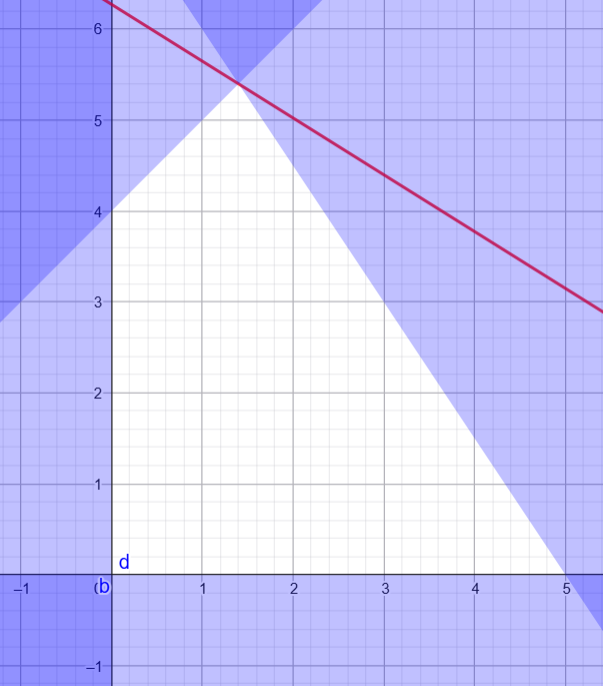

Impondo agora a ``condição`` de `variáveis inteiras`

In [3]:
print("2. Solução Primal (Inteiro)")

prob_ip = LpProblem("Primal_IP", LpMaximize)

x = LpVariable('x', lowBound=0, cat='Integer')
y = LpVariable('y', lowBound=0, cat='Integer')

prob_ip += 5*x + 8*y

prob_ip += 3*x + 2*y <= 15
prob_ip += x - y >= -4

prob_ip.solve()

print(f"Status: {LpStatus[prob_ip.status]}")
print(f"x1 = {value(x)}")
print(f"x2 = {value(y)}")
print(f"Valor Ótimo = {value(prob_ip.objective)}")

2. Solução Primal (Inteiro)
Status: Optimal
x1 = 1.0
x2 = 5.0
Valor Ótimo = 45.0


solução ``representada`` pelo `ponto vermelho` 

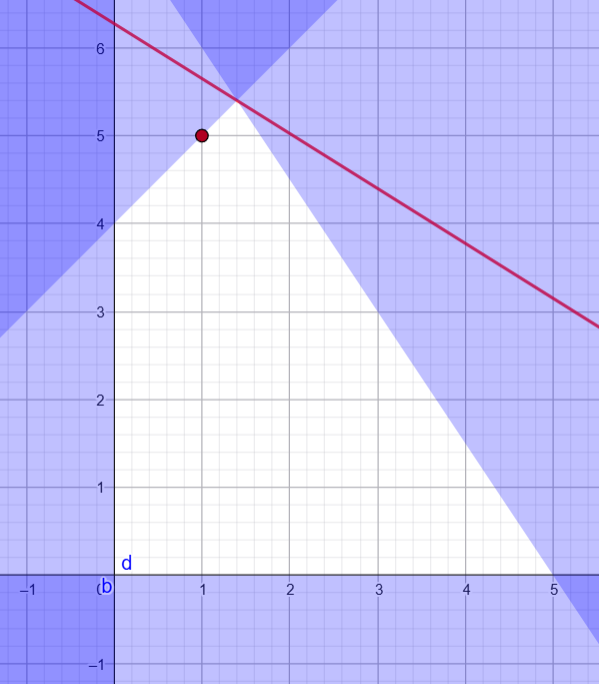

Um comentário apenas de ``curiosidade``: Analogamente à quando o ``problema não tem restrição inteira``, que as soluções se apresentam nos vértices da região viável, os ``problemas com restrição inteira`` tem suas soluções não mais necessariamente nos vértices, mas em algum ponto de suas arestas.

### Problema Dual

**Função Objetivo (Minimizar):**
`Z = 15y1 + 4y2`

**Sujeito às seguintes restrições:**
* `3y1 - y2 >= 5`
* `2y1 + y2 >= 8`
* `y1 >= 0 e y2 <= 0`

In [4]:
print("3. Solução Dual Linear Padrão")

prob_dual = LpProblem("Dual_LP", LpMinimize)

y1 = LpVariable('y1', lowBound=0, cat='Continuous')
y2 = LpVariable('y2', lowBound=0, cat='Continuous')

prob_dual += 15*y1 + 4*y2, "W"

prob_dual += 3*y1 - y2 >= 5, "C1_x1"
prob_dual += 2*y1 + y2 >= 8, "C2_x2"

prob_dual.solve()

print(f"Status: {LpStatus[prob_dual.status]}")
print(f"y1 = {value(y1)}")
print(f"y2 = {value(y2)}")
print(f"Valor Ótimo = {value(prob_dual.objective)}")
print("Nota: O valor ótimo do Dual LP (W_Dual) deve ser igual ao do Primal LP (Z_LP).")

3. Solução Dual Linear Padrão


Status: Optimal
y1 = 2.6
y2 = 2.8
Valor Ótimo = 50.2
Nota: O valor ótimo do Dual LP (W_Dual) deve ser igual ao do Primal LP (Z_LP).


Mais uma vez chegamos ao resultado que tivemos no livro: pelo ``teorema da dualidade forte``, o resultado é o mesmo do primal sem restrição de inteiro. Vamos agora para o ``dual com relaxação lagrangeana``. Lembrando que agora o nosso objetivo será obter uma cota entre a já estabelecida cota-dual \ solução-não-inteira e a solução inteira.

In [ ]:
print("4. Dual Lagrangeano via Geração de Colunas (para o problema dual dado)")

M_LARGE = 1000.0

columns = []

def solve_subproblem(pi1, pi2):
    subprob = LpProblem("Subproblem_Dual", LpMaximize)

    u = LpVariable('u', lowBound=0, upBound=M_LARGE, cat='Continuous')
    w = LpVariable('w', lowBound=0, upBound=M_LARGE, cat='Continuous')

    subprob += pi1 * (3*u - w) + pi2 * (2*u + w) - (15*u + 4*w), "Reduced_Cost" # temos as 2 condições como penalização

    subprob.solve(PULP_CBC_CMD(msg=False))

    sub_value = value(subprob.objective)

    new_col = {
        'u': value(u),
        'w': value(w),
        'a1': 3*value(u) - value(w),
        'a2': 2*value(u) + value(w),
        'cost': 15*value(u) + 4*value(w)
    }

    return sub_value, new_col

col0 = {'u': 0, 'w': 0, 'a1': 0, 'a2': 0, 'cost': 0}
columns.append(col0)

iteration = 0
max_iterations = 20
epsilon = 1e-6
W_val = None 

while iteration < max_iterations:
    iteration += 1
    print(f"\n--- Iteração GC {iteration} ---")

    pmr = LpProblem(f"PMR_Dual_{iteration}", LpMinimize)
    num_cols = len(columns)
    lambdas = LpVariable.dicts('lambda', range(num_cols), lowBound=0, cat='Continuous')

    S1 = LpVariable('S1_art', lowBound=0)
    S2 = LpVariable('S2_art', lowBound=0)

    pmr += lpSum(columns[k]['cost'] * lambdas[k] for k in range(num_cols)) \
           + M_LARGE * S1 + M_LARGE * S2, "W_PMR"

    pmr += lpSum(columns[k]['a1'] * lambdas[k] for k in range(num_cols)) + S1 >= 5, "R_x"
    pmr += lpSum(columns[k]['a2'] * lambdas[k] for k in range(num_cols)) + S2 >= 8, "R_y"
    
    pmr += lpSum(lambdas[k] for k in range(num_cols)) == 1, "Convexity"

    pmr.solve(PULP_CBC_CMD(msg=False))
    
    if pmr.status != LpStatusOptimal:
        print("PMR não encontrou solução ótima. Encerrando.")
        break

    W_val_penalized = value(pmr.objective)
    W_val = W_val_penalized - M_LARGE * (value(S1) + value(S2))

    pi1 = pmr.constraints["R_x"].pi
    pi2 = pmr.constraints["R_y"].pi
    sigma = pmr.constraints["Convexity"].pi

    if pi1 is None: pi1 = 0
    if pi2 is None: pi2 = 0
    if sigma is None: sigma = 0

    print(f"Preços duais: π₁={pi1:.4f}, π₂={pi2:.4f}, σ={sigma:.4f}")

    reduced_cost, new_col = solve_subproblem(pi1, pi2)
    
    print(f"Custo reduzido (max(πA - c)) = {reduced_cost:.4f}")

    if reduced_cost <= sigma + epsilon:
        print(f"Ótimo atingido: Custo Reduzido ({reduced_cost:.4f}) <= sigma ({sigma:.4f})")
        break
    else:
        print(f"Nova coluna adicionada: u={new_col['u']:.4f}, w={new_col['w']:.4f}")
        
        col_exists = False
        for col in columns:
            if abs(col['u'] - new_col['u']) < epsilon and abs(col['w'] - new_col['w']) < epsilon:
                col_exists = True
                break
        
        if not col_exists:
            columns.append(new_col)
        else:
            print("Coluna repetida, encerrando loop para evitar ciclos.")
            break

print("-" * 40)
print("4. Solução via Geração de Colunas — Dual")

def fmt(x):
    return f"{x:.4f}" if x is not None else "N/A"

print(f"Valor ótimo aproximado (W*) = {fmt(W_val)}")
print(f"Total de colunas geradas: {len(columns)}")

4. Dual Lagrangeano via Geração de Colunas (para o problema dual dado)

--- Iteração GC 1 ---
Preços duais: π₁=1000.0000, π₂=1000.0000, σ=0.0000
Custo reduzido (max(πA - c)) = 4985000.0000
Nova coluna adicionada: u=1000.0000, w=0.0000

--- Iteração GC 2 ---
Preços duais: π₁=0.0000, π₂=7.5000, σ=0.0000
Custo reduzido (max(πA - c)) = 3500.0000
Nova coluna adicionada: u=0.0000, w=1000.0000

--- Iteração GC 3 ---
Preços duais: π₁=1.4000, π₂=5.4000, σ=0.0000
Custo reduzido (max(πA - c)) = 0.0000
Ótimo atingido: Custo Reduzido (0.0000) <= sigma (0.0000)
----------------------------------------
4. Solução via Geração de Colunas — Dual
Valor ótimo aproximado (W*) = 50.2000
Total de colunas geradas: 3


Em alguns casos, a escolha de quais variáveis relaxar ou não pode impactar o resultado da relaxação lagrangeana, mas neste caso não há alterações pois ambas as condições são "simples". (ambas as condições foram usadas como penalização, diferentemente no problema exemplo onde uma das condições foi relaxada). Chegando a 2 conclusões importantes:
 - Não é sempre que a relaxação lagrangeana dará uma cota melhor que o dual padrão
 - O formato do problema (em especial as restrições) tem grande impacto nos resultados